In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import json
import seaborn as sns

In [2]:
# load in predictions from all models

SEQ_LENGTH = 24*7

with open('../data/processed/Lasso_preds.pkl', 'rb') as f:
    lasso_preds = pkl.load(f)

with open('../data/processed/OLS_preds.pkl', 'rb') as f:
    OLS_preds = pkl.load(f)

with open('../data/processed/XGBoost_preds.pkl', 'rb') as f:
    xgb_preds = pkl.load(f)

with open('../data/processed/naive_1wk_preds.pkl', 'rb') as f:
    naive_1wk_preds = pkl.load(f)

with open('../data/processed/naive_1hr_preds.pkl', 'rb') as f:
    naive_1hr_preds = pkl.load(f)

with open('../data/processed/LSTM_preds_dict.pkl', 'rb') as f:
    LSTM_preds = pkl.load(f)

# get datetimes of forecasted usage
datetime_for_tests_seq = xgb_preds.index.get_level_values('target_time').unique()
datetime_for_tests_LSTM = datetime_for_tests_seq[:len(datetime_for_tests_seq) - SEQ_LENGTH]

In [4]:
# concat the linear and tree based models to get df with all predictions
df_all_preds = df_all_preds = pd.concat((
                                xgb_preds.rename(columns={'y_pred': 'xgb'}),
                                lasso_preds.rename(columns={'y_pred': 'lasso'})['lasso'],
                                OLS_preds.rename(columns={'y_pred': 'OLS'})['OLS'],                     
                                naive_1hr_preds.rename(columns={'y_pred': 'naive_1hr'})['naive_1hr'],                     
                                naive_1wk_preds.rename(columns={'y_pred': 'naive_1wk'})['naive_1wk'],                     
                                        ), axis=1)

# reset and set index again to ensure datetime
df_all_preds.reset_index(inplace=True)
df_all_preds['datetime'] = pd.to_datetime(df_all_preds['target_time'])
df_all_preds.set_index(['datetime', 'client_id'], inplace=True)

In [21]:
for key in LSTM_preds.keys():
    print(len(LSTM_preds[key]))

6844
6844
6844
6844
6844
6844
6844
6844
6844
6852
6836
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6872
6816
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6860
6828
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6856
6832
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6856
6832
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6848
6840
6844
6844
6844
6844
6844
6844
6844
6844
6844
6844
6864
6824
6844
6844
6844
6844
6844
6844


In [5]:
# create dataframe from LSTM preds
df_LSTM = pd.DataFrame(LSTM_preds).set_index(datetime_for_tests_LSTM)
# take advantage of wide form to assign datetime (each row represents one datetime)
df_LSTM['datetime'] = datetime_for_tests_LSTM
# then melt so that client id becomes identifier column
df_LSTM = df_LSTM.melt(id_vars=['datetime']).rename(columns={'variable': 'client_id',
                                                             'value': 'LSTM'}).set_index(['datetime', 'client_id'])

In [9]:
# remove datetimes from other models that LSTM does not predict
df_all_preds_filtered = df_all_preds[df_all_preds.index.get_level_values('datetime').isin(datetime_for_tests_LSTM)]

In [10]:
# now concat LSTM and XGBoost together
df_all_preds_filtered = df_all_preds_filtered.join(df_LSTM, on=['datetime', 'client_id'], how='inner')

In [11]:
df_all_preds_filtered.iloc[1000:1010]

,,target_time,xgb,y_true,lasso,OLS,naive_1hr,naive_1wk,LSTM
datetime,client_id,,,,,,,,
2014-04-25 13:00:00,8,2014-04-25 13:00:00,306.418396,297.138047,315.063659,330.780838,305.555556,386.363636,289.194690
2014-04-25 14:00:00,8,2014-04-25 14:00:00,283.626892,240.740741,283.123147,290.463429,297.138047,292.929293,276.083245
2014-04-25 15:00:00,8,2014-04-25 15:00:00,266.009399,248.316498,271.556595,269.413986,240.740741,335.858586,263.411688
2014-04-25 16:00:00,8,2014-04-25 16:00:00,254.474152,229.797980,257.199880,261.717155,248.316498,291.245791,251.258233
2014-04-25 17:00:00,8,2014-04-25 17:00:00,241.128601,245.791246,249.439563,248.142150,229.797980,292.929293,271.642619
2014-04-25 18:00:00,8,2014-04-25 18:00:00,265.511414,238.215488,268.140355,271.622773,245.791246,322.390572,258.945437
2014-04-25 19:00:00,8,2014-04-25 19:00:00,263.536987,256.734007,268.907024,267.788155,238.215488,327.441077,275.148027
2014-04-25 20:00:00,8,2014-04-25 20:00:00,283.346375,278.619529,285.973518,289.138087,256.734007,343.434343,278.449307
2014-04-25 21:00:00,8,2014-04-25 21:00:00,284.123413,296.296296,282.347022,284.980137,278.619529,297.138047,278.938308


In [12]:
# save the filtered predictions
with open('../data/processed/df_all_preds', 'wb') as f:
    pkl.dump(df_all_preds, f)

In [13]:
df_all_preds_filtered.index.get_level_values('client_id').unique()

Index([  8,  12,  19,  21,  27,  31,  32,  33,  45,  46,  49,  50,  51,  53,
        54,  55,  56,  57,  60,  70,  71,  75,  77,  79,  83,  84,  87,  92,
        96, 100, 114, 125, 132, 134, 135, 136, 139, 140, 141, 146, 149, 150,
       152, 154, 161, 170, 172, 175, 176, 177, 183, 189, 194, 203, 204, 205,
       211, 212, 213, 216, 218, 221, 228, 235, 238, 239, 250, 251, 257, 258,
       259, 262, 266, 284, 285, 288, 296, 298, 302, 303, 307, 309, 312, 317,
       319, 326, 328, 330, 331, 340, 341, 350, 351, 352, 353, 355, 359, 363,
       365, 368],
      dtype='int32', name='client_id')

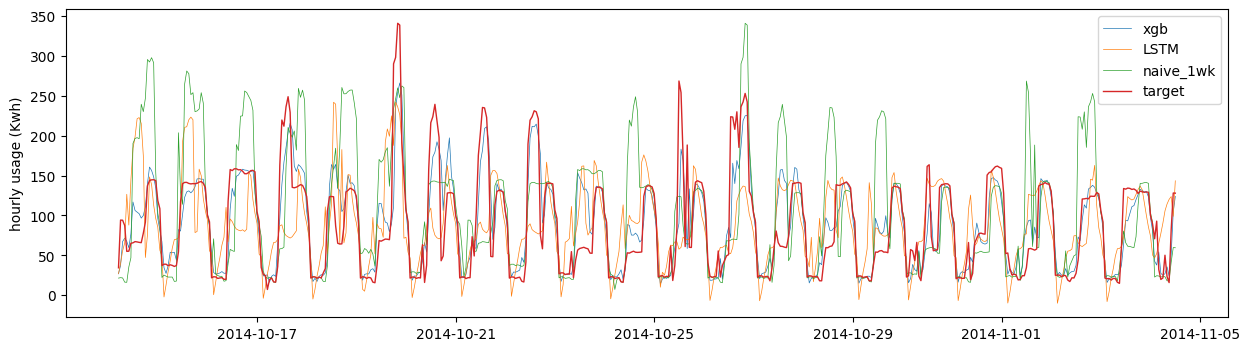

In [15]:
# plot all predictions for a bad client

#TODO: actually check that top/bottom five worst are indeed that
plt.figure(figsize=(15, 4))
linewidth_others = 0.5


start_idx = 128*40
idx_range_to_plot = int(4*128)
client_to_plot = 352

datetimes = df_all_preds_filtered.index.get_level_values('datetime')
df_all_preds_for_plot = df_all_preds_filtered[df_all_preds_filtered.index.get_level_values('client_id') == client_to_plot].iloc[start_idx: start_idx + idx_range_to_plot]


plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['xgb'], label='xgb', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['LSTM'], label='LSTM', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['lasso'], label='lasso', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['OLS'], label='OLS', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['naive_1hr'], label='naive_1hr', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['naive_1wk'], label='naive_1wk', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['y_true'], label='target', linewidth=1.0)



plt.ylabel('hourly usage (Kwh)')
plt.legend()
plt.show()

In [ ]:
# df_preds_corr = df_all_preds_filtered.corr()

In [28]:
# load in standardised data

with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    y_preds_standardised = pkl.load(f)['hourly_usage_kwh']

In [30]:
std_per_client = y_preds_standardised.to_frame().groupby(level='client_id').std()

In [97]:
coeff_var = df_all_preds_filtered.groupby(level='client_id')['y_true'].std()/df_all_preds_filtered.groupby(level='client_id')['y_true'].mean()
highest_5_cv = coeff_var.sort_values().iloc[-10:]
# normalised_variance.sort_values().iloc[:10]
highest_5_cv

# convert index to string
highest_5_cv.index = highest_5_cv.index.astype(str)

In [59]:
with open('../logs/XGBoost/nrmse_per_client.json', 'r') as f:
    XGBoost_per_client_nrmse = json.load(f)

with open('../logs/lasso/nrmse_per_client.json', 'r') as f:
    lasso_per_client_nrmse = json.load(f)

with open('../logs/OLS/nrmse_per_client.json', 'r') as f:
    OLS_per_client_nrmse = json.load(f)

with open('../logs/naive_1hr/nrmse_per_client.json', 'r') as f:
    naive_1hr_per_client_nrmse = json.load(f)

with open('../logs/naive_1wk/nrmse_per_client.json', 'r') as f:
    naive_1wk_per_client_nrmse = json.load(f)

with open('../logs/LSTM/nrmse_per_client.json', 'r') as f:
    LSTM_per_client_nrmse = json.load(f)
    client_ids = list(LSTM_per_client_nrmse.keys())
    LSTM_values = list(LSTM_per_client_nrmse.values())

In [60]:
df_all_nrmse = pd.DataFrame({
                            'naive_1hr': naive_1hr_per_client_nrmse, 
                            'naive_1wk': naive_1wk_per_client_nrmse, 
                            'OLS': OLS_per_client_nrmse, 
                            'lasso': lasso_per_client_nrmse, 
                            'xgb': XGBoost_per_client_nrmse, 
                            'LSTM': LSTM_per_client_nrmse, 
                            }, index=client_ids)

In [98]:
# drop clients with highest cv
df_minus_CV_clients = df_all_nrmse[~df_all_nrmse.index.isin(highest_5_cv.index)]
df_CV_clients = df_all_nrmse[df_all_nrmse.index.isin(highest_5_cv.index)]

In [106]:
# df_CV_clients
df_all_nrmse.mean(axis=1).sort_values().iloc[-10:]

136    0.177929
80     0.192561
84     0.192620
23     0.207590
343    0.239243
164    0.249645
354    0.298100
36     0.332914
366    0.384960
132    0.698126
dtype: float64

In [100]:
df_minus_CV_clients.mean()

naive_1hr    0.129219
naive_1wk    0.132312
OLS          0.084196
lasso        0.096487
xgb          0.070836
LSTM         0.108840
dtype: float64

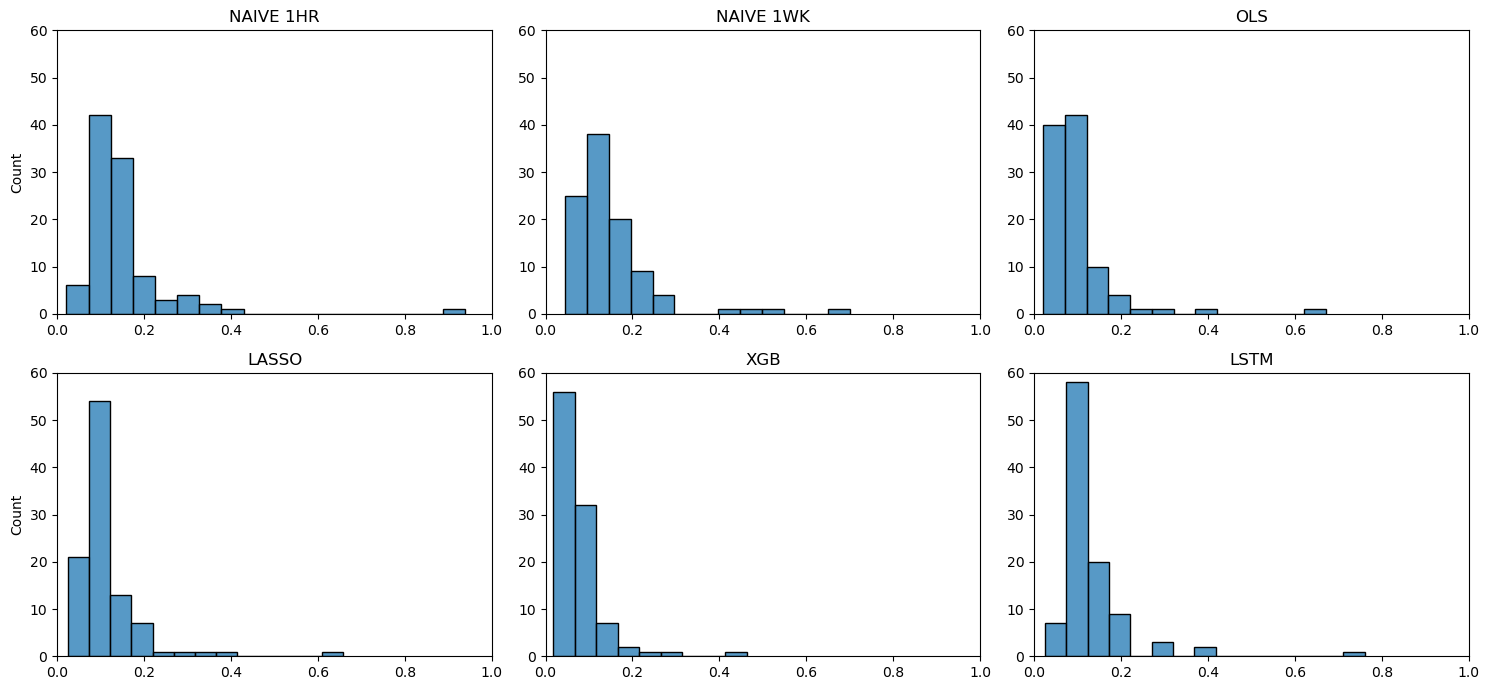

In [146]:
# create histogram of errors across clients

fig, axis = plt.subplots(2, 3, figsize=(15, 7))

for i, ax in enumerate(axis.flatten()):

    sns.histplot(data=df_all_nrmse.iloc[:, i], ax=ax, binwidth=0.05)
    ax.set_xlabel('')
    if i == 0 or i == 3:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')
    ax.set_title(f'{df_all_nrmse.columns[i]}'.replace('_', ' ').upper())
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 60])
# plt.suptitle('Per-client error distribution', fontsize=30)
plt.tight_layout()
plt.savefig('../plots/client_error_histogram.png')
plt.show()